In [58]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification


In [59]:
SEED = 42
tf.random.set_seed(SEED)

## Carga de los datos (sinthetic data)
Usaremos la librera sklearn para generar unos datos sinteticos(inventados) con las caracteristicas que necesitamos

In [60]:
X, y = make_classification(
    n_samples= 1000,
    n_features= 20,
    n_informative= 5,
    n_redundant= 15,
    random_state=SEED
)

In [61]:
print(X.shape)
print(y.shape)
print(type(X))
print(type(y))

(1000, 20)
(1000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## Exploracion del conjunto de datos

In [62]:
# Convertir nuestro array en un DataFrame de Pandas
X_df = pd.DataFrame(X,columns=[f'feature{i}'for i in range(X.shape[1])])
y_df = pd.Series(y,name='target')

# Concatenamos las features con target
data_df = pd.concat((X_df,y_df),axis=1)

In [63]:
# Visualizacion de los datos
print(data_df.head())

   feature0  feature1  feature2  feature3  feature4  feature5  feature6  \
0 -1.643060 -1.297794 -2.752168 -2.278346 -1.197356 -0.018829  1.721003   
1  0.189733 -0.471632  1.250216 -0.893140 -0.034495 -0.640767  0.162411   
2 -1.283225  1.278070 -1.535286 -1.041253 -0.809182  0.004057  0.163880   
3 -0.319824 -3.449154  1.044185 -0.670927  2.002038 -2.411686 -0.290792   
4 -0.944149  0.374291 -0.643719 -3.219326 -2.297094 -3.031796  0.971777   

   feature7  feature8  feature9  ...  feature11  feature12  feature13  \
0  0.595004  1.599303 -1.605647  ...  -1.867307  -2.342453  -1.393649   
1 -0.688193  0.802312  0.128458  ...   0.020331  -0.179985   0.515407   
2  0.756917  1.318729 -0.850419  ...  -1.900428  -1.697117  -0.840642   
3 -1.644750 -0.075478 -1.007836  ...  -1.035058  -0.130101   0.565386   
4 -1.078391  3.592326 -1.056837  ...  -4.834348  -2.112767  -1.701690   

   feature14  feature15  feature16  feature17  feature18  feature19  target  
0   0.237435   0.268309   2.7613

In [64]:
data_df.describe()

,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature11,feature12,feature13,feature14,feature15,feature16,feature17,feature18,feature19,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.714111,0.809316,0.355613,-0.288013,0.603485,-0.087584,-0.687929,0.208416,0.525651,-0.348179,...,-0.500426,-0.833224,0.461654,0.499845,0.469059,-0.011035,-0.570093,-0.492447,0.480472,0.501000
std,1.798258,2.095277,2.651684,2.060041,2.185706,2.313893,1.789085,1.608007,1.803432,1.448871,...,2.583003,1.923243,1.612656,1.621358,1.489777,1.618548,2.990855,1.518933,1.583809,0.500249
min,-6.415972,-7.701454,-7.083158,-6.484166,-5.771672,-7.820671,-7.572213,-4.574992,-4.737023,-4.817602,...,-7.713013,-6.184029,-4.429313,-4.341477,-3.889284,-5.814203,-9.163417,-4.258034,-4.661168,0.000000
25%,-1.859282,-0.430351,-1.441289,-1.574968,-0.747751,-1.697565,-1.745556,-0.943780,-0.658521,-1.252045,...,-2.280225,-2.231042,-0.621774,-0.674893,-0.609955,-1.132212,-2.536397,-1.504082,-0.542215,0.000000
50%,-1.099322,0.842834,0.360410,-0.593695,0.634585,-0.277281,-0.685532,0.304775,0.757537,-0.632544,...,-0.938583,-1.067953,0.705280,0.449055,0.541561,0.029747,-1.012076,-0.760929,0.583361,1.000000
75%,0.466143,2.029835,2.139661,0.966419,1.844233,1.440340,0.422702,1.378943,1.751139,0.607999,...,1.026342,0.341294,1.636720,1.531734,1.447875,1.077206,1.230368,0.230285,1.521656,1.000000
max,4.845315,7.889681,6.608334,6.393069,9.266909,8.780182,6.487386,4.993885,6.221291,4.562247,...,9.013998,6.041796,4.696692,5.608412,6.036793,4.605669,10.080468,5.685693,5.066061,1.000000


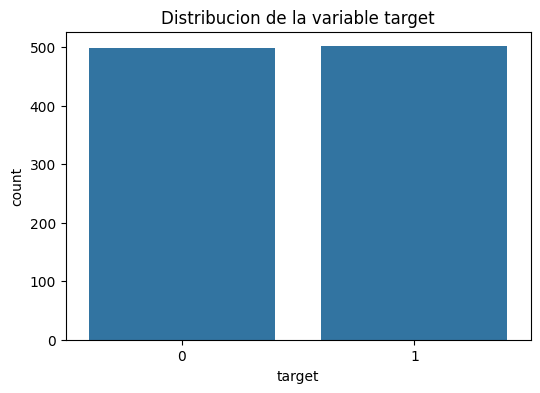

In [65]:
# Distribucion de la variable target

plt.figure(figsize=[6,4])
sns.countplot(data=data_df,x='target')
plt.title('Distribucion de la variable target')
plt.show()

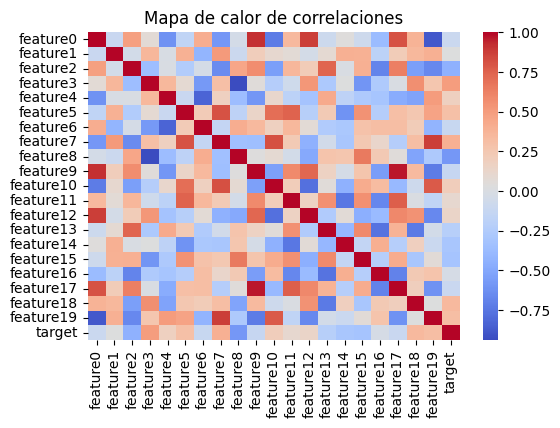

In [66]:
# Grafico de correlaciones entre variables
#data_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(data=data_df.corr(),annot=False,cmap='coolwarm')
plt.title('Mapa de calor de correlaciones')
plt.show()


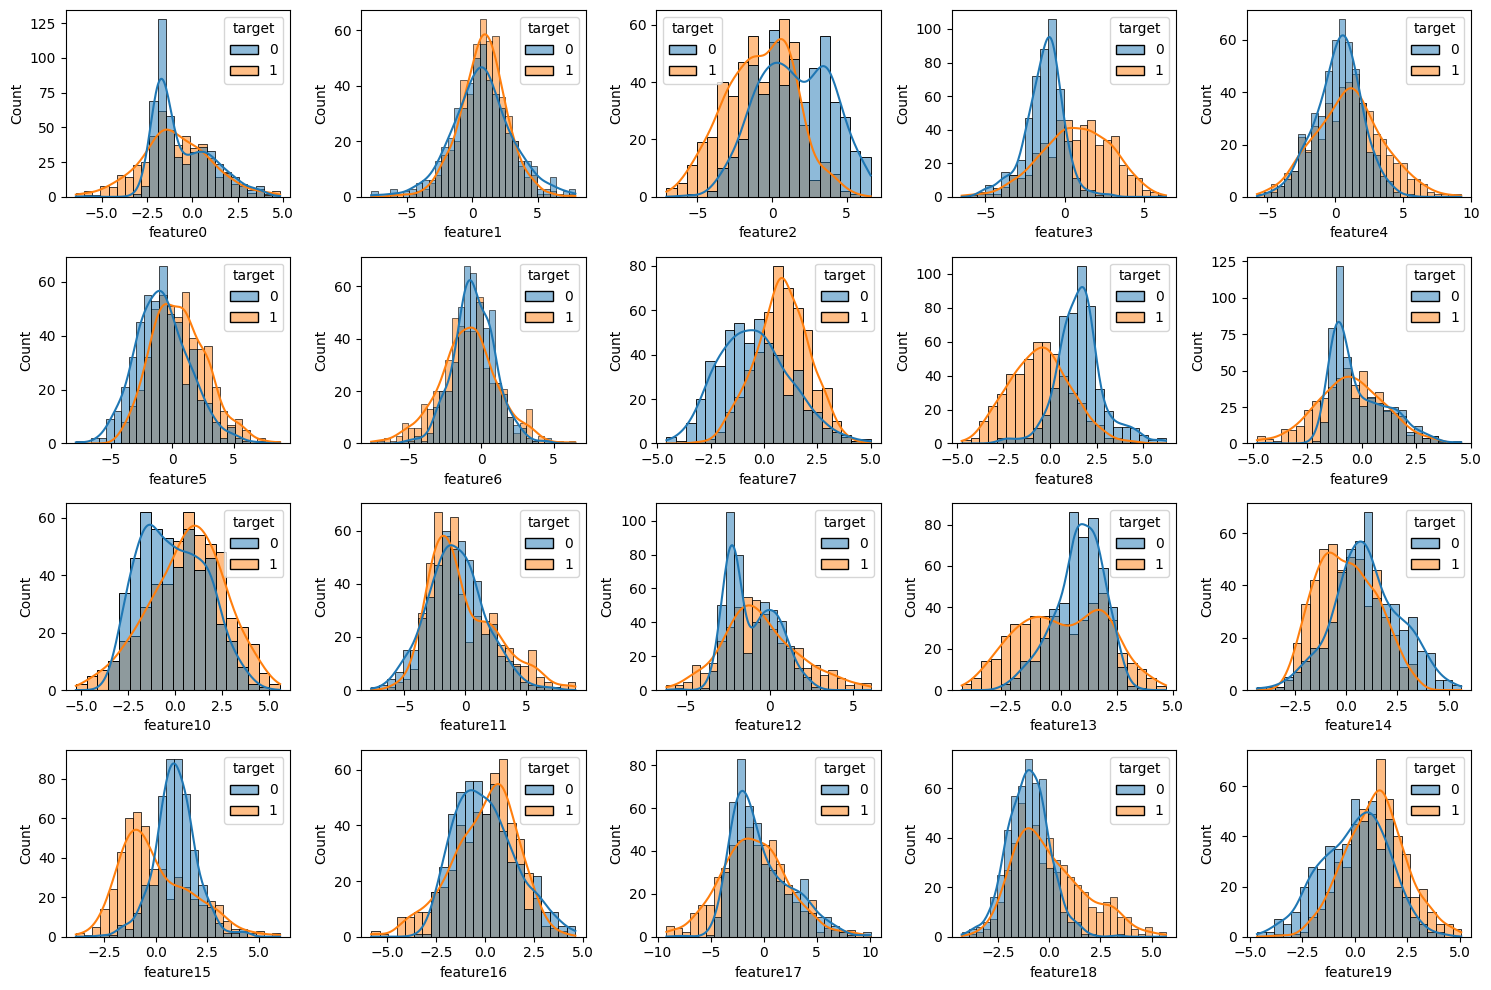

In [67]:
# Grafico de distribucion de variables

fig, axes = plt.subplots(4,5,figsize=(15,10))
for i, ax in enumerate(axes.flatten()):
    sns.histplot(data=data_df,x=f'feature{i}',hue='target',ax=ax, kde=True)
plt.tight_layout()
plt.show()

## Preprocesamiento del conjunto de datos

In [68]:
# Division de los datos Train-Test
X_train, X_test,y_train, y_test = train_test_split(
    X, y,
    test_size= 0.3,
    random_state= SEED,
)

In [69]:
# Estandarizar datos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [70]:
X_train.shape

(700, 20)

## Entrenamiento

In [71]:
model = Sequential()

model.add(Dense(10, activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(1, activation= 'sigmoid'))
model.summary()

/home/jaume/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [73]:
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_split = 0.20,
    batch_size = 50
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5161 - loss: 1.0984 - val_accuracy: 0.5429 - val_loss: 1.0124
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5250 - loss: 0.9960 - val_accuracy: 0.5500 - val_loss: 0.9228
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5214 - loss: 0.9055 - val_accuracy: 0.5571 - val_loss: 0.8427
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5429 - loss: 0.8264 - val_accuracy: 0.5929 - val_loss: 0.7734
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5554 - loss: 0.7597 - val_accuracy: 0.6214 - val_loss: 0.7147
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5964 - loss: 0.7043 - val_accuracy: 0.6214 - val_loss: 0.6649
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6321 - loss: 0.6575 - val_accuracy: 0.6714 - val_loss: 0.6216
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6607 - loss: 0.6174 - val_accuracy: 0.7071 - val_loss

In [74]:
def plot_history(history):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Evolution')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Evolution')
    plt.legend()

    plt.show()

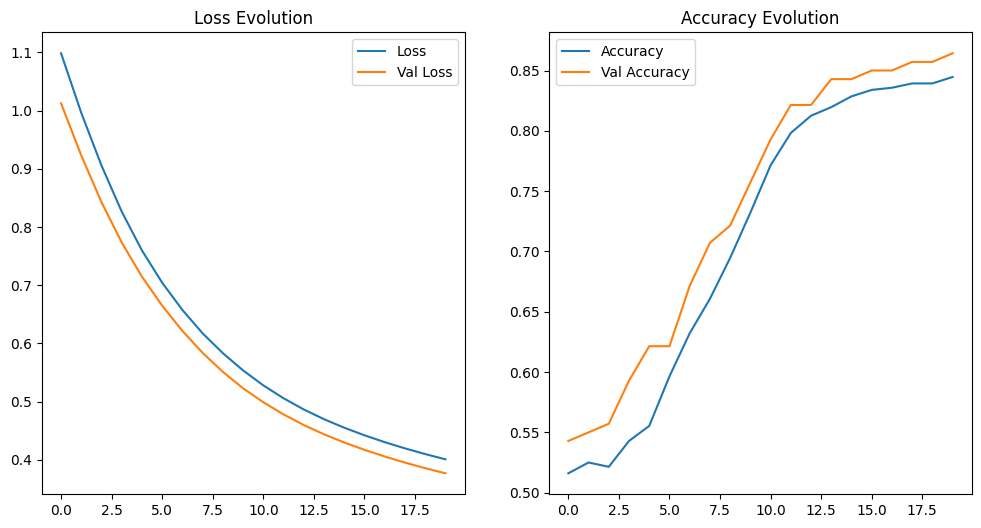

In [75]:
plot_history(history)

## Cambiamos la estructura del modelo para probocar un sobreajuste

In [76]:
model = Sequential()

model.add(Dense(1000, activation='relu',input_shape=(X_train.shape[1],)))
for _ in range(12):
    model.add(Dense(1000, activation='relu'))
model.add(Dense(1, activation= 'sigmoid'))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_77 (Dense)                │ (None, 1000)           │        21,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,034,001 (45.91 MB)

 Trainable params: 12,034,001 (45.91 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [78]:
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_split = 0.20,
    batch_size = 50
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.5125 - loss: 0.6874 - val_accuracy: 0.4714 - val_loss: 0.6609
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7286 - loss: 0.5650 - val_accuracy: 0.8786 - val_loss: 0.4380
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8893 - loss: 0.3287 - val_accuracy: 0.7286 - val_loss: 0.8096
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8286 - loss: 0.4164 - val_accuracy: 0.8643 - val_loss: 0.2353
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8857 - loss: 0.3140 - val_accuracy: 0.9357 - val_loss: 0.2472
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9214 - loss: 0.2153 - val_accuracy: 0.9429 - val_loss: 0.2000
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9321 - loss: 0.1554 - val_accuracy: 0.9000 - val_loss: 0.1885
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9107 - loss: 0.1883 - val_accuracy: 0.8714 - v

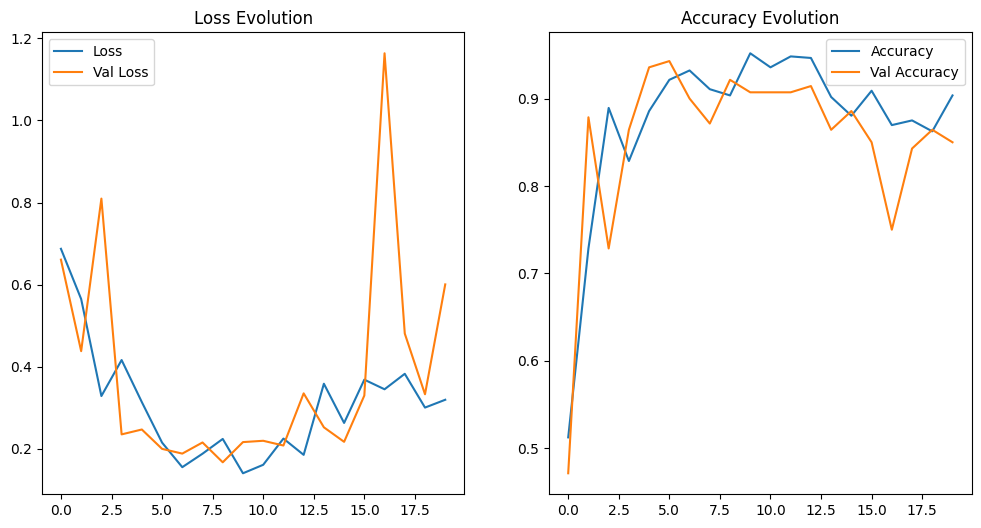

In [79]:
plot_history(history)

# Implementacion de metodos de regularizacion

## Dropout

In [80]:
model = Sequential()

model.add(Dense(1000, activation='relu',input_shape=(X_train.shape[1],)))
for _ in range(12):
    model.add(Dropout(0.5)) # Regularizacion. Dropout al 50% por el gran tamaño de la red
    model.add(Dense(1000, activation='relu'))
model.add(Dense(1, activation= 'sigmoid'))
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_91 (Dense)                │ (None, 1000)           │        21,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 1000)           │     1,001,00

 Total params: 12,034,001 (45.91 MB)

 Trainable params: 12,034,001 (45.91 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [82]:
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_split = 0.20,
    batch_size = 50
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5036 - loss: 0.7454 - val_accuracy: 0.6786 - val_loss: 0.6888
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.5411 - loss: 0.6965 - val_accuracy: 0.8214 - val_loss: 0.6639
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.5732 - loss: 0.6336 - val_accuracy: 0.8071 - val_loss: 0.5875
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8286 - loss: 0.4865 - val_accuracy: 0.8214 - val_loss: 0.4225
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8268 - loss: 0.4301 - val_accuracy: 0.9286 - val_loss: 0.2439
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8714 - loss: 0.3130 - val_accuracy: 0.9000 - val_loss: 0.2053
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8893 - loss: 0.2557 - val_accuracy: 0.8714 - val_loss: 0.2379
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8786 - loss: 0.3308 - val_accuracy: 0.9143 - v

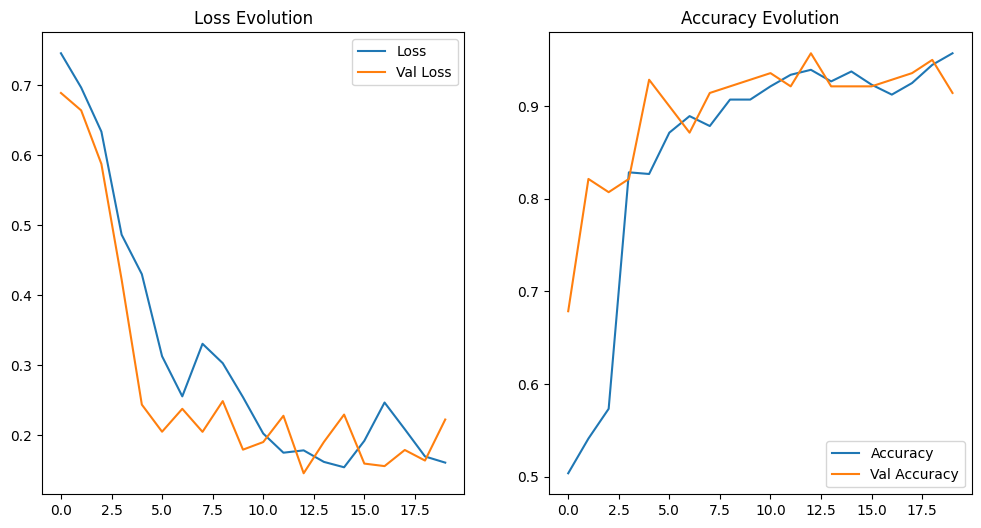

In [83]:
plot_history(history)

## Early Stoping

In [84]:
model = Sequential()

model.add(Dense(1000, activation='relu',input_shape=(X_train.shape[1],)))
for _ in range(12):
    model.add(Dense(1000, activation='relu'))
model.add(Dense(1, activation= 'sigmoid'))
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_105 (Dense)               │ (None, 1000)           │        21,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,034,001 (45.91 MB)

 Trainable params: 12,034,001 (45.91 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [86]:
callbacks = [EarlyStopping(monitor='val_loss',patience=2)]
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_split = 0.20,
    batch_size = 50,
    callbacks = callbacks
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.6304 - loss: 0.6492 - val_accuracy: 0.8500 - val_loss: 0.3657
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.8893 - loss: 0.3263 - val_accuracy: 0.7571 - val_loss: 0.6302
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8018 - loss: 0.4998 - val_accuracy: 0.8500 - val_loss: 0.2892
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9143 - loss: 0.2653 - val_accuracy: 0.8929 - val_loss: 0.2175
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9143 - loss: 0.2247 - val_accuracy: 0.9000 - val_loss: 0.1848
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9357 - loss: 0.1752 - val_accuracy: 0.8786 - val_loss: 0.2159
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9375 - loss: 0.1637 - val_accuracy: 0.9000 - val_loss: 0.1995


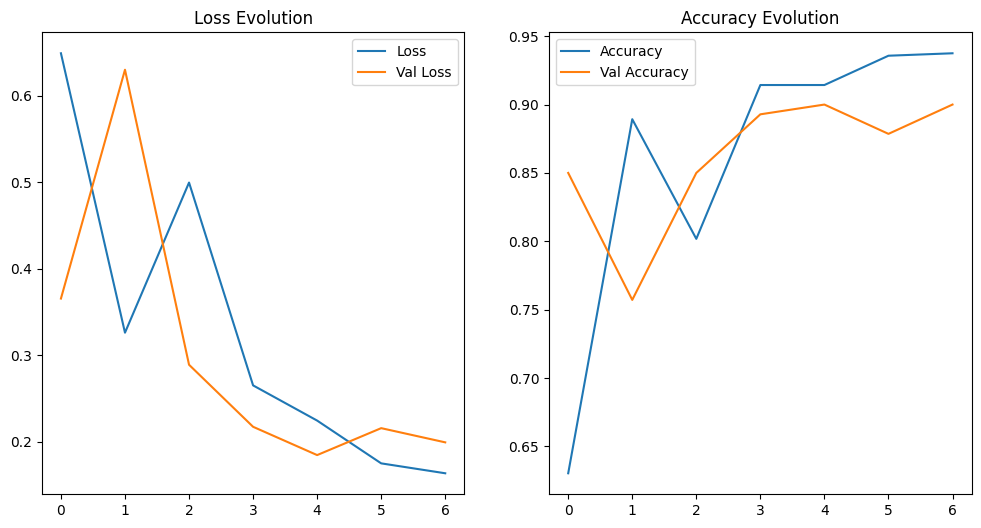

In [87]:
plot_history(history)

## Batch normalization

In [88]:
model = Sequential()

model.add(Dense(1000, activation='relu',input_shape=(X_train.shape[1],)))
for _ in range(12):
    model.add(BatchNormalization())
    model.add(Dense(1000, activation='relu'))
model.add(Dense(1, activation= 'sigmoid'))
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_119 (Dense)               │ (None, 1000)           │        21,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │             

 Total params: 12,082,001 (46.09 MB)

 Trainable params: 12,058,001 (46.00 MB)

 Non-trainable params: 24,000 (93.75 KB)

In [89]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [90]:
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_split = 0.20,
    batch_size = 50,
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.7839 - loss: 0.6780 - val_accuracy: 0.4929 - val_loss: 0.6822
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8375 - loss: 0.6026 - val_accuracy: 0.8143 - val_loss: 0.4869
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8464 - loss: 0.3539 - val_accuracy: 0.9071 - val_loss: 0.2780
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8821 - loss: 0.2714 - val_accuracy: 0.8643 - val_loss: 0.2456
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9554 - loss: 0.1155 - val_accuracy: 0.7857 - val_loss: 0.3429
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9732 - loss: 0.0818 - val_accuracy: 0.9214 - val_loss: 0.1876
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9750 - loss: 0.0683 - val_accuracy: 0.8643 - val_loss: 0.2378
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9839 - loss: 0.0442 - val_accuracy: 0.8429 - v

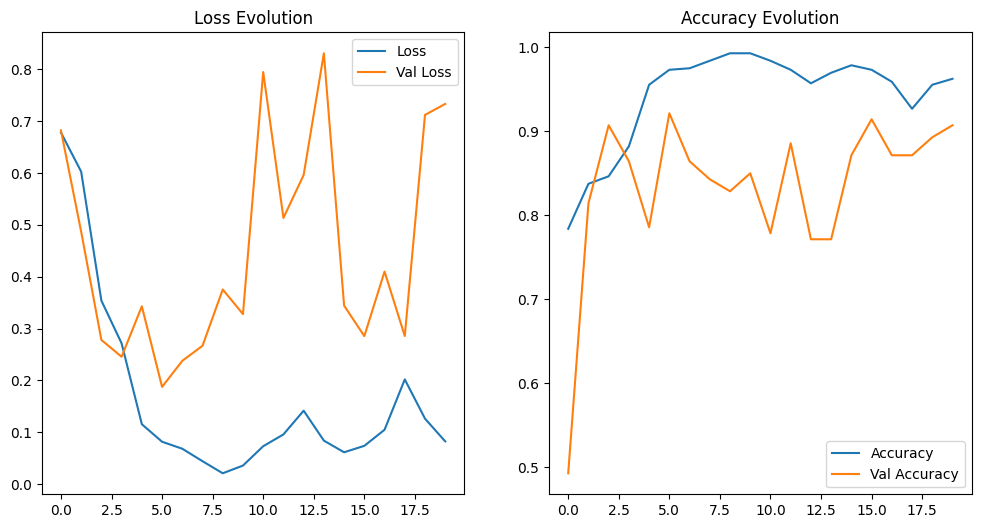

In [91]:
plot_history(history)